# 03 — Entrenamiento y Evaluación de Modelos
## Sistema inteligente para la detección y predicción de degradación de conectividad WiFi
**Autor:** Juan Vásquez  
**Universidad:** UDLA — Maestría en Inteligencia Artificial Aplicada  
**Fecha:** 2026

### Estructura
1. Configuración de reproducibilidad
2. Carga del dataset final
3. División estratificada del dataset (70/15/15)
4. Modelo baseline — Regresión Logística
5. Modelo candidato — Random Forest
6. Modelo candidato — XGBoost
7. Evaluación final en conjunto de prueba
8. Comparación de modelos y selección
9. Importancia de variables del modelo seleccionado
10. Exportación del modelo seleccionado

## 1. Configuración de reproducibilidad

Se fija la semilla aleatoria en todos los componentes estocásticos
para garantizar resultados reproducibles entre ejecuciones (SEED=42).

In [15]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga del dataset final

Se carga el dataset procesado y listo para entrenamiento,
generado por el notebook de feature engineering.

In [16]:
df = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\Dataset_horizonte_30.csv")
print(f"Shape: {df.shape}")
print("\nDistribución de clases:")
print(df["etiqueta_futura"].value_counts())

Shape: (7268, 84)

Distribución de clases:
etiqueta_futura
normal       5308
degradada     984
critica       976
Name: count, dtype: int64


## 3. División estratificada del dataset (70/15/15)

Se aplica división estratificada para preservar la proporción de clases
en cada subconjunto. El conjunto de prueba se reserva y se utiliza
una única vez al final para la evaluación definitiva.

- **70%** → entrenamiento
- **15%** → validación (ajuste de hiperparámetros)
- **15%** → prueba (evaluación final, uso único)

In [17]:
X = df.drop(columns=["timestamp", "etiqueta_conectividad", "etiqueta_futura"])
y = df["etiqueta_futura"]

# Eliminar NaN residuales de ventanas deslizantes en bordes de sesión
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]
print(f"Filas totales  : {len(X) + (~mask).sum()}")
print(f"Filas eliminadas: {(~mask).sum()}")
print(f"Filas finales  : {len(X)}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"\nEntrenamiento : {X_train.shape}")
print(f"Validación    : {X_val.shape}")
print(f"Prueba        : {X_test.shape}")

print("\nDistribución entrenamiento:")
print(y_train.value_counts())
print("\nDistribución validación:")
print(y_val.value_counts())
print("\nDistribución prueba:")
print(y_test.value_counts())

Filas totales  : 7268
Filas eliminadas: 29
Filas finales  : 7239

Entrenamiento : (5067, 81)
Validación    : (1086, 81)
Prueba        : (1086, 81)

Distribución entrenamiento:
etiqueta_futura
normal       3697
degradada     687
critica       683
Name: count, dtype: int64

Distribución validación:
etiqueta_futura
normal       792
degradada    147
critica      147
Name: count, dtype: int64

Distribución prueba:
etiqueta_futura
normal       792
degradada    148
critica      146
Name: count, dtype: int64


## 4. Modelo Baseline — Regresión Logística

La Regresión Logística es un clasificador supervisado lineal que se emplea
como baseline por su simplicidad y bajo costo computacional. Establece la
referencia mínima de desempeño que los modelos candidatos deben superar
para justificar su mayor complejidad.

`class_weight='balanced'` compensa el desbalance de clases y `max_iter=1000`
garantiza convergencia del optimizador.

In [18]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED
)
lr_model.fit(X_train, y_train)

y_pred_lr_test = lr_model.predict(X_test)

print("Reporte Baseline — Regresión Logística (conjunto de prueba):")
print(classification_report(y_test, y_pred_lr_test, zero_division=0))
f1_lr = f1_score(y_test, y_pred_lr_test, average="macro")
acc_lr = accuracy_score(y_test, y_pred_lr_test)
print(f"F1-macro : {f1_lr:.4f}")
print(f"Accuracy : {acc_lr:.4f}")

Reporte Baseline — Regresión Logística (conjunto de prueba):
              precision    recall  f1-score   support

     critica       0.24      0.36      0.28       146
   degradada       0.41      0.42      0.41       148
      normal       0.86      0.77      0.81       792

    accuracy                           0.67      1086
   macro avg       0.50      0.52      0.50      1086
weighted avg       0.71      0.67      0.69      1086

F1-macro : 0.5036
Accuracy : 0.6685


C:\Users\juanj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Modelo candidato — Random Forest

Random Forest construye múltiples árboles de decisión sobre submuestras
aleatorias del dataset y combina sus predicciones por votación mayoritaria.
`class_weight='balanced'` asigna mayor peso a las clases minoritarias
durante el entrenamiento sin necesidad de remuestreo.

### 5.1 Búsqueda de hiperparámetros — GridSearchCV (Random Forest)

Validación cruzada estratificada k=5 sobre el conjunto de entrenamiento,
optimizando F1-macro para penalizar el mal desempeño en clases minoritarias.

In [19]:
param_grid_rf = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"Mejores parámetros RF  : {rf_grid.best_params_}")
print(f"Mejor F1-macro (CV)    : {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros RF  : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Mejor F1-macro (CV)    : 0.6336


### 5.2 Entrenamiento final y evaluación en validación (Random Forest)

Se entrena el modelo con los hiperparámetros óptimos encontrados por
GridSearchCV y se evalúa en el conjunto de validación para detectar
posible sobreajuste antes de la evaluación definitiva.

In [20]:
rf_final = RandomForestClassifier(
    **rf_grid.best_params_,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred_rf_val = rf_final.predict(X_val)
print("Random Forest — validación:")
print(classification_report(y_val, y_pred_rf_val, zero_division=0))
print(f"F1-macro validación: {f1_score(y_val, y_pred_rf_val, average='macro'):.4f}")

Random Forest — validación:
              precision    recall  f1-score   support

     critica       0.52      0.52      0.52       147
   degradada       0.59      0.50      0.54       147
      normal       0.89      0.91      0.90       792

    accuracy                           0.80      1086
   macro avg       0.67      0.64      0.65      1086
weighted avg       0.80      0.80      0.80      1086

F1-macro validación: 0.6536


## 6. Modelo candidato — XGBoost

XGBoost construye árboles de forma secuencial y aditiva: cada árbol
corrige los errores del anterior mediante optimización de gradiente.
Incorpora regularización nativa que reduce el riesgo de sobreajuste.

XGBoost requiere etiquetas numéricas, por lo que se aplica un
`LabelEncoder` antes del entrenamiento.

### 6.1 Codificación de etiquetas y búsqueda de hiperparámetros — GridSearchCV (XGBoost)

In [21]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Mapeo de clases:", dict(zip(le.classes_, le.transform(le.classes_))))

param_grid_xgb = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    ),
    param_grid_xgb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train_enc)

print(f"Mejores parámetros XGB : {xgb_grid.best_params_}")
print(f"Mejor F1-macro (CV)    : {xgb_grid.best_score_:.4f}")

Mapeo de clases: {'critica': np.int64(0), 'degradada': np.int64(1), 'normal': np.int64(2)}
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros XGB : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}
Mejor F1-macro (CV)    : 0.6512


### 6.2 Entrenamiento final y evaluación en validación (XGBoost)

In [22]:
xgb_final = xgb_grid.best_estimator_

y_pred_xgb_val = le.inverse_transform(xgb_final.predict(X_val))
print("XGBoost — validación:")
print(classification_report(y_val, y_pred_xgb_val, zero_division=0))
print(f"F1-macro validación: {f1_score(y_val, y_pred_xgb_val, average='macro'):.4f}")

XGBoost — validación:
              precision    recall  f1-score   support

     critica       0.64      0.47      0.54       147
   degradada       0.69      0.46      0.55       147
      normal       0.88      0.98      0.93       792

    accuracy                           0.84      1086
   macro avg       0.74      0.63      0.67      1086
weighted avg       0.82      0.84      0.82      1086

F1-macro validación: 0.6728


## 7. Evaluación final en conjunto de prueba

Ambos modelos candidatos se evalúan **una única vez** sobre el conjunto
de prueba reservado. Este es el resultado definitivo sobre el que se
toma la decisión de selección.

### 7.1 Evaluación final — Random Forest

Reporte final — Random Forest (conjunto de prueba):
              precision    recall  f1-score   support

     critica       0.48      0.45      0.47       146
   degradada       0.57      0.49      0.52       148
      normal       0.88      0.92      0.90       792

    accuracy                           0.80      1086
   macro avg       0.64      0.62      0.63      1086
weighted avg       0.79      0.80      0.79      1086

F1-macro : 0.6299
Accuracy : 0.7956


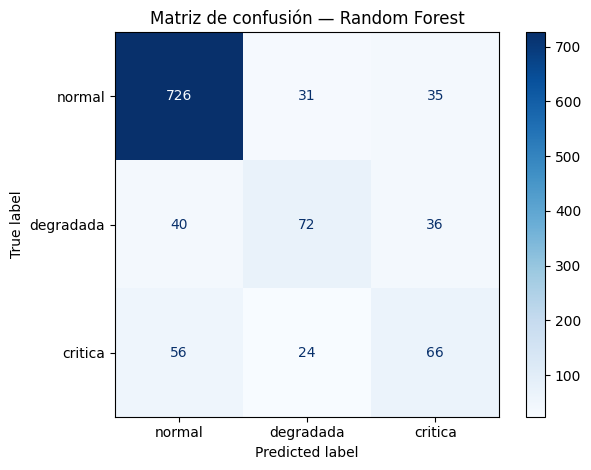

In [23]:
y_pred_rf_test = rf_final.predict(X_test)

print("Reporte final — Random Forest (conjunto de prueba):")
print(classification_report(y_test, y_pred_rf_test, zero_division=0))
f1_rf = f1_score(y_test, y_pred_rf_test, average="macro")
acc_rf = accuracy_score(y_test, y_pred_rf_test)
print(f"F1-macro : {f1_rf:.4f}")
print(f"Accuracy : {acc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf_test, labels=["normal", "degradada", "critica"])
ConfusionMatrixDisplay(cm_rf, display_labels=["normal", "degradada", "critica"]).plot(cmap="Blues")
plt.title("Matriz de confusión — Random Forest")
plt.tight_layout()
plt.show()

### 7.2 Evaluación final — XGBoost

Reporte final — XGBoost (conjunto de prueba):
              precision    recall  f1-score   support

     critica       0.59      0.43      0.50       146
   degradada       0.66      0.44      0.53       148
      normal       0.89      0.99      0.93       792

    accuracy                           0.84      1086
   macro avg       0.71      0.62      0.65      1086
weighted avg       0.82      0.84      0.82      1086

F1-macro : 0.6533
Accuracy : 0.8370


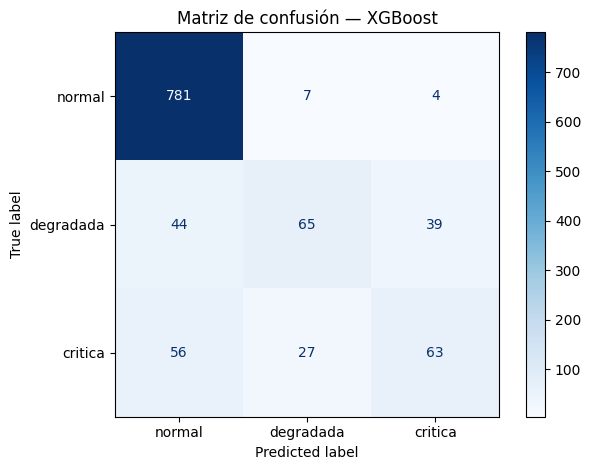

In [24]:
y_pred_xgb_test = le.inverse_transform(xgb_final.predict(X_test))

print("Reporte final — XGBoost (conjunto de prueba):")
print(classification_report(y_test, y_pred_xgb_test, zero_division=0))
f1_xgb = f1_score(y_test, y_pred_xgb_test, average="macro")
acc_xgb = accuracy_score(y_test, y_pred_xgb_test)
print(f"F1-macro : {f1_xgb:.4f}")
print(f"Accuracy : {acc_xgb:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb_test, labels=["normal", "degradada", "critica"])
ConfusionMatrixDisplay(cm_xgb, display_labels=["normal", "degradada", "critica"]).plot(cmap="Blues")
plt.title("Matriz de confusión — XGBoost")
plt.tight_layout()
plt.show()

## 8. Comparación de modelos y selección

Se consolidan los resultados de los tres modelos y se determina
automáticamente el candidato con mejor F1-macro en prueba.
Ese modelo es el que se exportará para producción.

                        Modelo  F1-macro  Accuracy  F1 Normal  F1 Degradada  F1 Crítica
Regresión Logística (baseline)    0.5036    0.6685     0.8127        0.4147      0.2834
                 Random Forest    0.6299    0.7956     0.8996        0.5236      0.4664
                       XGBoost    0.6533    0.8370     0.9337        0.5263      0.5000


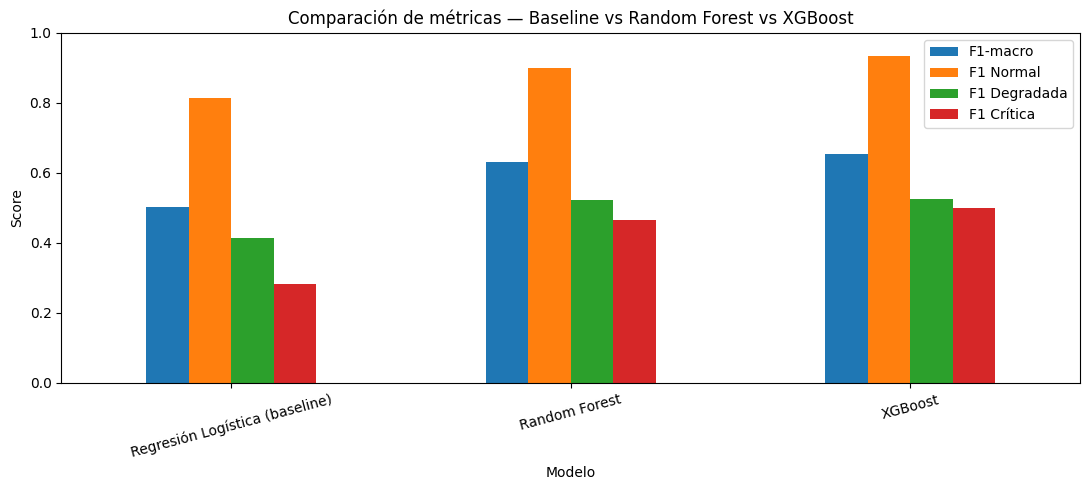


Modelo seleccionado: XGBoost
F1-macro en prueba : 0.6533


In [25]:
def f1_clase(y_true, y_pred, clase):
    return f1_score(y_true, y_pred, labels=[clase], average="macro", zero_division=0)

resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística (baseline)",
        "Random Forest",
        "XGBoost"
    ],
    "F1-macro": [
        round(f1_lr,  4),
        round(f1_rf,  4),
        round(f1_xgb, 4)
    ],
    "Accuracy": [
        round(acc_lr,  4),
        round(acc_rf,  4),
        round(acc_xgb, 4)
    ],
    "F1 Normal": [
        round(f1_clase(y_test, y_pred_lr_test,  "normal"), 4),
        round(f1_clase(y_test, y_pred_rf_test,  "normal"), 4),
        round(f1_clase(y_test, y_pred_xgb_test, "normal"), 4)
    ],
    "F1 Degradada": [
        round(f1_clase(y_test, y_pred_lr_test,  "degradada"), 4),
        round(f1_clase(y_test, y_pred_rf_test,  "degradada"), 4),
        round(f1_clase(y_test, y_pred_xgb_test, "degradada"), 4)
    ],
    "F1 Crítica": [
        round(f1_clase(y_test, y_pred_lr_test,  "critica"), 4),
        round(f1_clase(y_test, y_pred_rf_test,  "critica"), 4),
        round(f1_clase(y_test, y_pred_xgb_test, "critica"), 4)
    ]
})

print(resultados.to_string(index=False))

# Gráfico
resultados.set_index("Modelo")[["F1-macro", "F1 Normal", "F1 Degradada", "F1 Crítica"]].plot(
    kind="bar", figsize=(11, 5), rot=15
)
plt.title("Comparación de métricas — Baseline vs Random Forest vs XGBoost")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Selección automática por F1-macro
candidatos = {
    "Random Forest": f1_rf,
    "XGBoost"      : f1_xgb
}
nombre_ganador = max(candidatos, key=candidatos.get)
modelo_ganador = rf_final if nombre_ganador == "Random Forest" else xgb_final

print(f"\n{'='*50}")
print(f"Modelo seleccionado: {nombre_ganador}")
print(f"F1-macro en prueba : {candidatos[nombre_ganador]:.4f}")
print(f"{'='*50}")

## 9. Importancia de variables del modelo seleccionado

Se analiza la contribución de cada variable al modelo seleccionado.
Para Random Forest se usa `feature_importances_`; para XGBoost,
`feature_importances_` también está disponible (ganancia promedio).

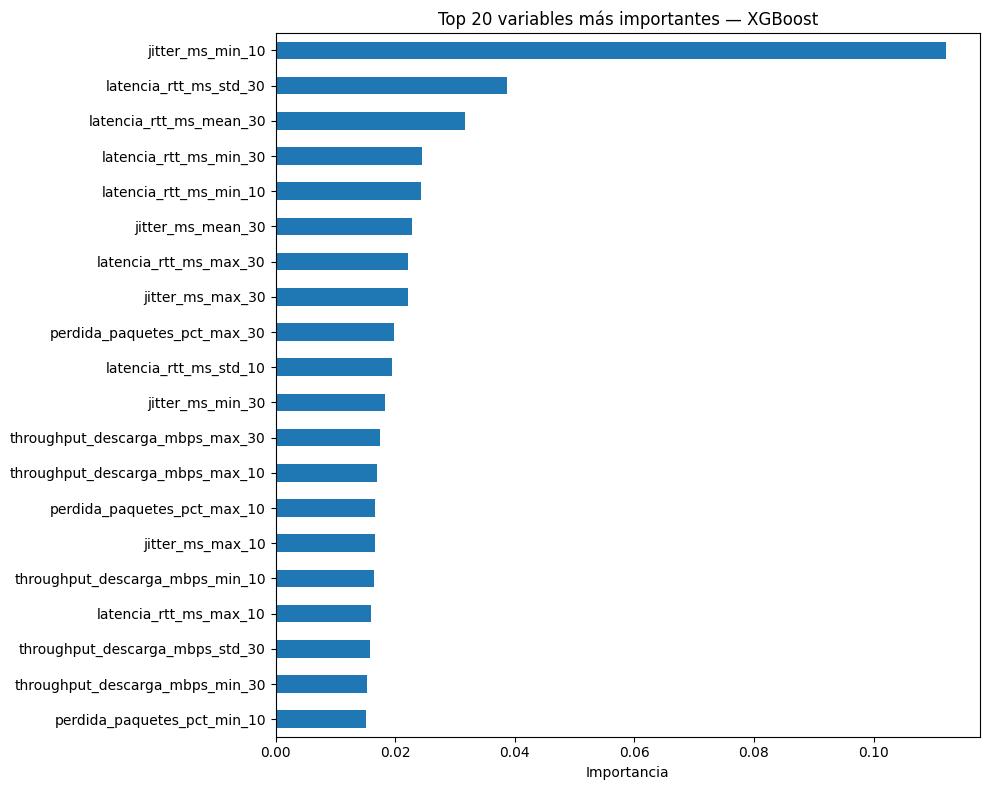


Top 10 variables:
jitter_ms_min_10               0.112195
latencia_rtt_ms_std_30         0.038735
latencia_rtt_ms_mean_30        0.031619
latencia_rtt_ms_min_30         0.024544
latencia_rtt_ms_min_10         0.024295
jitter_ms_mean_30              0.022815
latencia_rtt_ms_max_30         0.022108
jitter_ms_max_30               0.022095
perdida_paquetes_pct_max_30    0.019879
latencia_rtt_ms_std_10         0.019410
dtype: float32


In [26]:
importancias = pd.Series(
    modelo_ganador.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importancias.head(20).plot(kind="barh")
plt.title(f"Top 20 variables más importantes — {nombre_ganador}")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 variables:")
print(importancias.head(10))

## 10. Exportación del modelo seleccionado

Se serializa el modelo con mejor F1-macro en prueba para su uso
en el dashboard Streamlit y la API REST Flask.

In [27]:
RUTA_MODELOS = r"C:\Users\juanj\Desktop\Maestría\Tesis\Modelos"

joblib.dump(modelo_ganador, f"{RUTA_MODELOS}\\modelo_qos.pkl")
print(f"Modelo exportado : {nombre_ganador} → modelo_qos.pkl")

# Si el ganador es XGBoost también guardamos el LabelEncoder
if nombre_ganador == "XGBoost":
    joblib.dump(le, f"{RUTA_MODELOS}\\label_encoder.pkl")
    print("LabelEncoder exportado → label_encoder.pkl")

columnas = X_train.columns.tolist()
with open(f"{RUTA_MODELOS}\\columnas_modelo.json", "w") as f:
    json.dump({"modelo": nombre_ganador, "columnas": columnas}, f, indent=2)
print("Columnas exportadas → columnas_modelo.json")

Modelo exportado : XGBoost → modelo_qos.pkl
LabelEncoder exportado → label_encoder.pkl
Columnas exportadas → columnas_modelo.json
